In [ ]:
# Financial News Sentiment Analysis - EDA

## Overview
In this notebook I explore the financial news dataset to understand 
its structure, content and patterns before doing sentiment analysis.

The dataset contains over 1.4 million news headlines from 2009 to 2020.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("ready")

ready


In [ ]:
df_news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df_news.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [ ]:
print("Shape of data:", df_news.shape)
print("Columns:", df_news.columns.tolist())

Shape of data: (1407328, 6)
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


In [ ]:
print("Missing values in each column:")
print(df_news.isnull().sum())

Missing values in each column:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


In [ ]:
print("Number of unique stocks:", df_news['stock'].nunique())
print("Number of unique publishers:", df_news['publisher'].nunique())
print("\nTop 10 publishers:")
print(df_news['publisher'].value_counts().head(10))

Number of unique stocks: 6204
Number of unique publishers: 1034

Top 10 publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [17]:
# Add a new column that counts how many words are in each headline
df_news['headline_length'] = df_news['headline'].apply(len)

print("Headline length statistics:")
print(df_news['headline_length'].describe())

Headline length statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


## Publisher Analysis
This shows the top 10 publishers by number of articles written.
Paul Quintaro is the most active with over 228,000 articles.

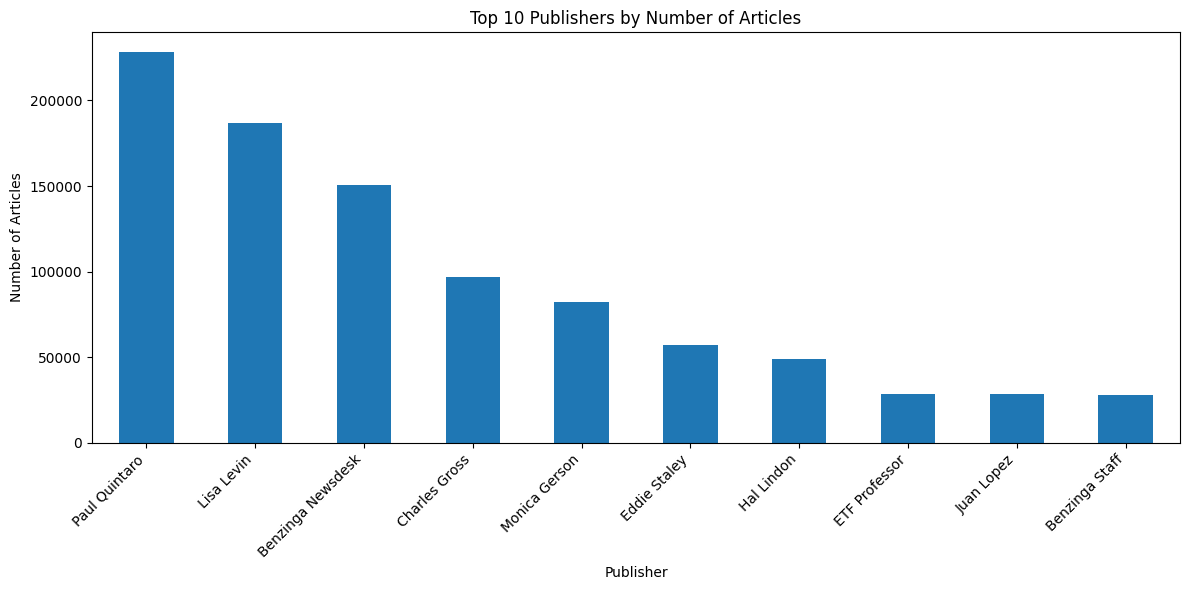

In [24]:
plt.figure(figsize=(12, 6))
df_news['publisher'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Publishers by Number of Articles')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Headline Length Analysis
Most headlines are between 47 and 87 characters long.
The average headline length is 73 characters.

In [ ]:
plt.figure(figsize=(12, 6))
df_news['headline_length'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Headline Length (characters)')
plt.ylabel('Number of Headlines')
plt.tight_layout()
plt.show()

In [28]:
# Convert date column to proper date format
df_news['date'] = pd.to_datetime(df_news['date'], format='mixed', utc=True)

# Extract just the date (without time)
df_news['date_only'] = df_news['date'].dt.date

print("Date range of news:")
print("Earliest:", df_news['date'].min())
print("Latest:", df_news['date'].max())

Date range of news:
Earliest: 2009-02-14 00:00:00+00:00
Latest: 2020-06-11 21:12:35+00:00


## News Volume Over Time
This shows how many articles were published each year.
We can see which years had the most financial news activity.

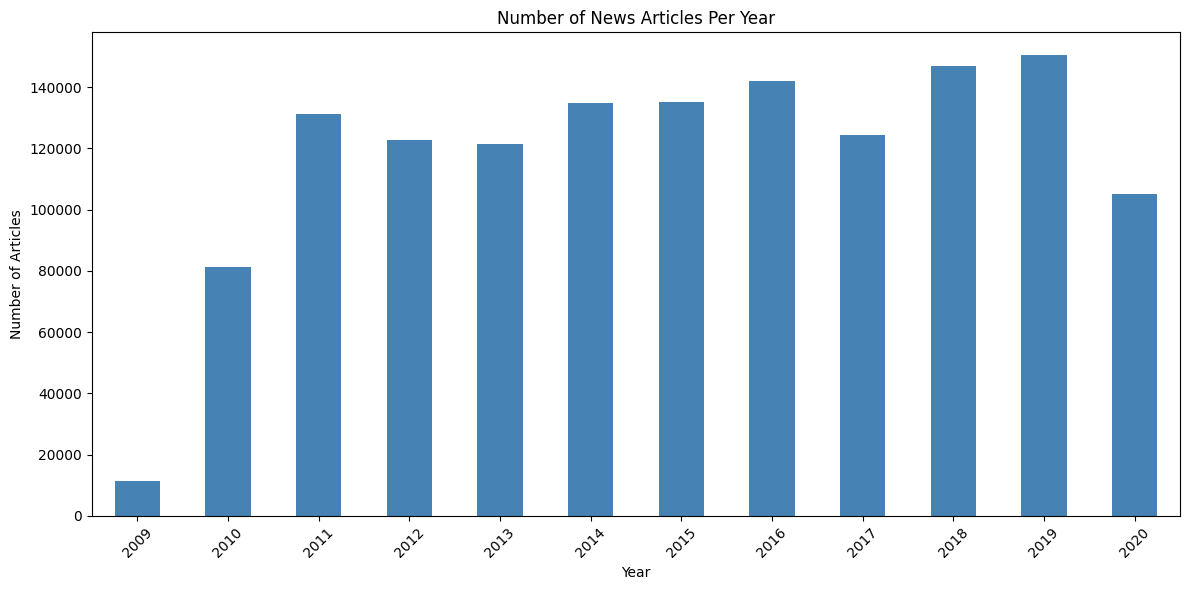

In [ ]:
# Count articles per year
df_news['year'] = df_news['date'].dt.year

plt.figure(figsize=(12, 6))
df_news['year'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Number of News Articles Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("=== NEWS DATASET SUMMARY ===")
print(f"Total headlines: {df_news.shape[0]:,}")
print(f"Total columns: {df_news.shape[1]}")
print(f"Unique stocks: {df_news['stock'].nunique():,}")
print(f"Unique publishers: {df_news['publisher'].nunique():,}")
print(f"Date range: {df_news['date'].min()} to {df_news['date'].max()}")
print(f"Average headline length: {df_news['headline_length'].mean():.0f} characters")

=== NEWS DATASET SUMMARY ===
Total headlines: 1,407,328
Total columns: 9
Unique stocks: 6,204
Unique publishers: 1,034
Date range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
Average headline length: 73 characters
